In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных
df = sns.load_dataset('planets')

# Проверка данных
print("Размер датасета:", df.shape)
print("\nПропущенные значения:")
print(df.isnull().sum())
df_clean = df.dropna(subset=['method', 'mass', 'orbital_period']).copy()
print(f"\nОчищенный датасет: {df_clean.shape}")

Размер датасета: (1035, 6)

Пропущенные значения:
method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64

Очищенный датасет: (513, 6)


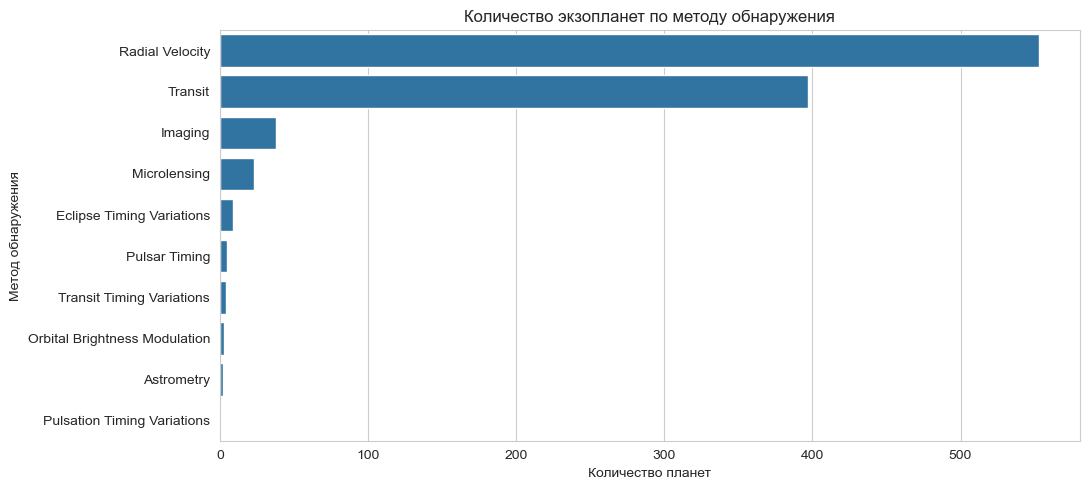

In [21]:
# 1. Построить countplot по методу обнаружения.

plt.figure(figsize=(11, 5))
sns.countplot(data=df, y='method', order=df['method'].value_counts().index)
plt.title('Количество экзопланет по методу обнаружения')
plt.xlabel('Количество планет')
plt.ylabel('Метод обнаружения')
plt.tight_layout()
plt.show()

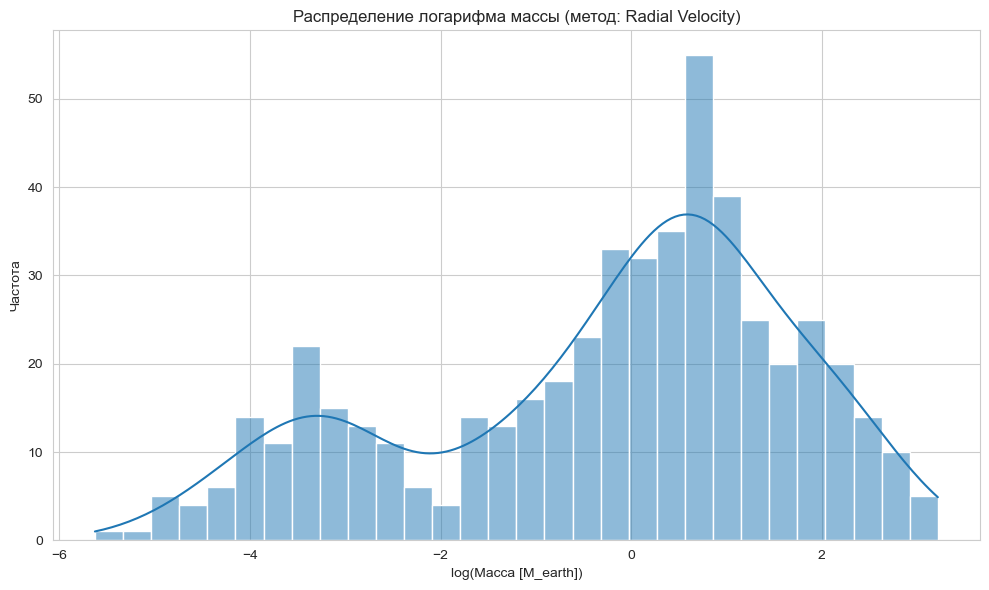

In [11]:
# 2. Построить гистограмму логарифма массы (np.log(mass)) для планет, открытых методом Radial Velocity.

df_rv = df_clean[df_clean['method'] == 'Radial Velocity'].copy()
df_rv['log_mass'] = np.log(df_rv['mass'].clip(lower=0.001)) 

plt.figure(figsize=(10, 6))
sns.histplot(data=df_rv, x='log_mass', bins=30, kde=True)
plt.title('Распределение логарифма массы (метод: Radial Velocity)')
plt.xlabel('log(Масса [M_earth])') 
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

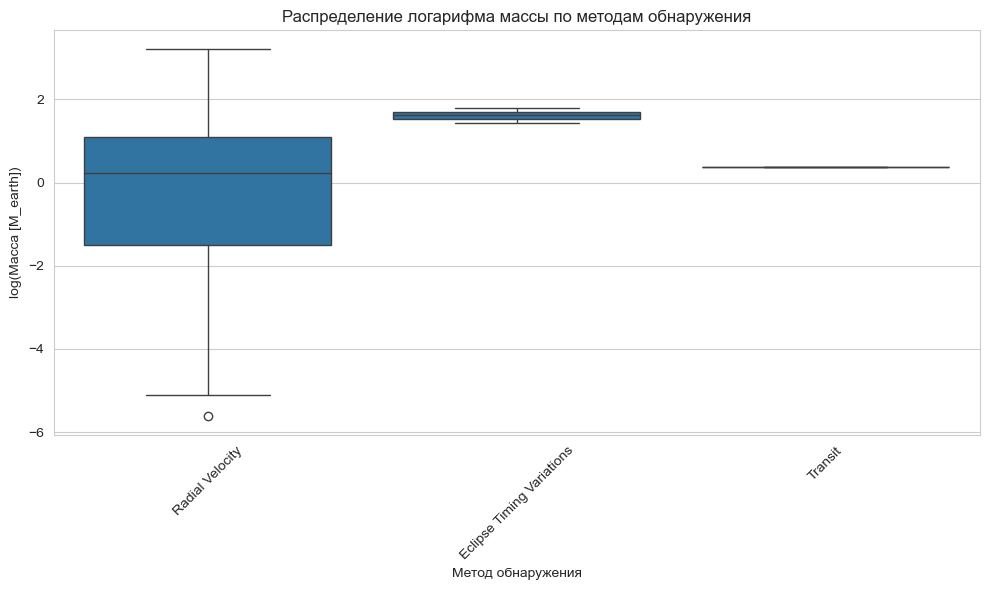

In [12]:
# 3. Построить boxplot массы по методу обнаружения (можно логарифмированную массу).

top_methods = df_clean['method'].value_counts().nlargest(5).index
df_top = df_clean[df_clean['method'].isin(top_methods)].copy()
df_top['log_mass'] = np.log(df_top['mass'].clip(lower=0.001))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top, x='method', y='log_mass')
plt.title('Распределение логарифма массы по методам обнаружения')
plt.xlabel('Метод обнаружения')
plt.ylabel('log(Масса [M_earth])')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


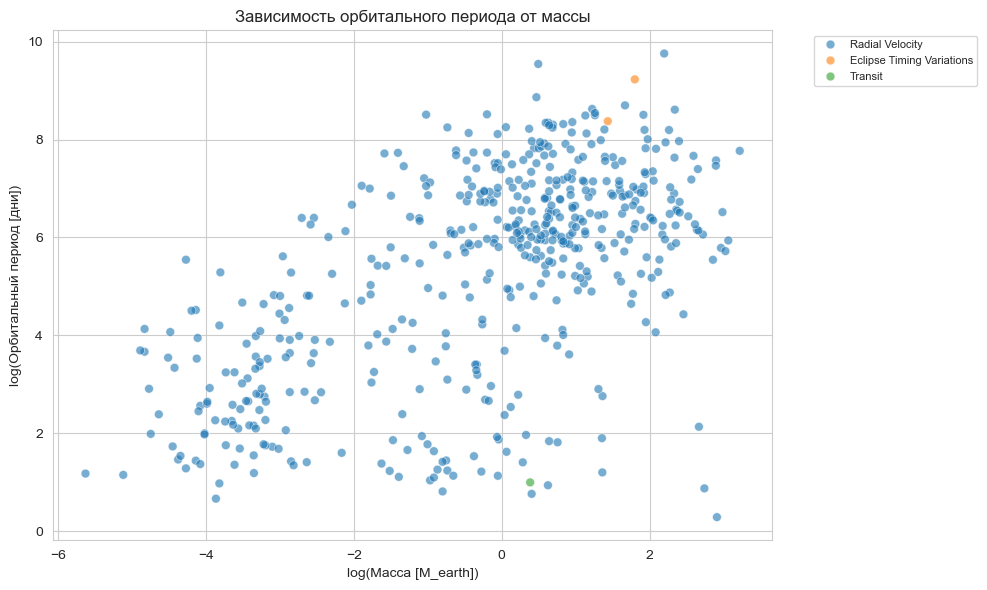

In [13]:
# 4. Построить scatter plot зависимости орбитального периода от массы.

df_clean['log_mass'] = np.log(df_clean['mass'].clip(lower=0.001))
df_clean['log_period'] = np.log(df_clean['orbital_period'].clip(lower=0.001))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='log_mass', y='log_period', hue='method', alpha=0.6, s=40)
plt.title('Зависимость орбитального периода от массы')
plt.xlabel('log(Масса [M_earth])') 
plt.ylabel('log(Орбитальный период [дни])')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# Вывод статистики
print("Всего записей:", len(df))
print("Открыто планет по годам:\n", df['year'].value_counts().sort_index().tail(10))
print("\nТоп методов обнаружения:\n", df['method'].value_counts().head(5))


Всего записей: 1035
Открыто планет по годам:
 year
2005     39
2006     31
2007     53
2008     74
2009     98
2010    102
2011    185
2012    140
2013    118
2014     52
Name: count, dtype: int64

Топ методов обнаружения:
 method
Radial Velocity              553
Transit                      397
Imaging                       38
Microlensing                  23
Eclipse Timing Variations      9
Name: count, dtype: int64
